# Ley de Paschen

### Joshua Briones Andrade

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df1 = pd.read_excel(r'./datos/Datosrotativo1.xlsx', sheet_name=[0,1,2], skiprows=[1], index_col=None)
df2 = pd.read_excel(r'./datos/Paschenairedistancia10cm.xlsx', sheet_name=[0,1,2], skiprows=[1], index_col=None)
df2[0].head()

,Presion por distancia (10cm) [m*Torr],Voltaje [V]
0,0.00072,1352.0
1,0.00080,748.0
2,0.00098,587.0
3,0.00120,342.0
4,0.00140,346.0


In [3]:
pdist = []; voltaje = [];

for i in range(3):
    pdist.append(df1[i].iloc[:,0].to_numpy())
    voltaje.append(df1[i].iloc[:,1].to_numpy())
    
for i in range(3):
    pdist.append(df2[i].iloc[:,0].to_numpy())
    voltaje.append(df2[i].iloc[:,1].to_numpy())

$$ V_r(pd) = \frac{B pd}{\text{ln}(pd)+P_1} $$

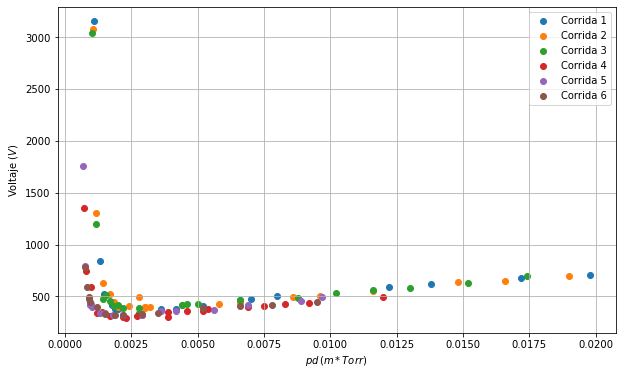

In [4]:
plt.figure(figsize=(10,6)); plt.grid()

labels = []
for k in range(6):
    labels.append("Corrida "+str(k+1))
    plt.scatter(pdist[k],voltaje[k], label=labels[k])

plt.xlabel(r"$pd\, (m*Torr)$")
plt.ylabel(r"Voltaje ($V$)")
plt.legend(); plt.show()


$$ P_1 = \ln\left(\frac{A}{\ln(1+1/\gamma)}\right) $$


In [5]:
B = 60; P = 6.915 

def V_r(X, B, P):
    t1 = B * X * 10000    #por 10 mil 
    t2 = np.log(X) + P
    return t1 / t2

def costo(k, B, P):
    return np.sum(np.abs(V_r(pdist[k], B, P) - voltaje[k]))/1000
    
costo(0, B, P)

34.162938695725934

In [6]:
from deap import tools
from deap import algorithms

def eaSimpleWithElitism(population, toolbox, cxpb, mutpb, ngen, stats=None,
             halloffame=None, verbose=__debug__):
    """This algorithm is similar to DEAP eaSimple() algorithm, with the modification that
    halloffame is used to implement an elitism mechanism. The individuals contained in the
    halloffame are directly injected into the next generation and are not subject to the
    genetic operators of selection, crossover and mutation.
    """
    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    if halloffame is None:
        raise ValueError("halloffame parameter must not be empty!")

    halloffame.update(population)
    hof_size = len(halloffame.items) if halloffame.items else 0

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(invalid_ind), **record)
    if verbose:
        print(logbook.stream)

    # Begin the generational process
    for gen in range(1, ngen + 1):

        # Select the next generation individuals
        offspring = toolbox.select(population, len(population) - hof_size)

        # Vary the pool of individuals
        offspring = algorithms.varAnd(offspring, toolbox, cxpb, mutpb)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # add the best back to population:
        offspring.extend(halloffame.items)

        # Update the hall of fame with the generated individuals
        halloffame.update(offspring)

        # Replace the current population by the offspring
        population[:] = offspring

        # Append the current generation statistics to the logbook
        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

    return population, logbook

C:\ProgramData\Anaconda3\lib\site-packages\deap\creator.py:138: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\ProgramData\Anaconda3\lib\site-packages\deap\creator.py:138: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	min    	avg   
0  	500   	93.2955	909798
1  	417   	72.1552	12050.3
2  	403   	72.1552	2377   
3  	396   	40.3159	2044.35
4  	406   	40.3159	224387 
5  	395   	40.3159	8936.24
6  	396   	37.4974	35414.2
7  	402   	37.4974	220218 
8  	383   	36.7406	87142  
9  	386   	36.7406	82750.2
10 	394   	36.4619	333010 
11 	383   	36.4619	794574 
12 	401   	36.4619	9845.5 
13 	415   	36.4369	32082.2
14 	392   	36.4347	15514.8
15 	389   	36.4347	18960  
16 	410   	36.4347	37432.2
17 	415   	36.4347	182901 
18 	402   	36.4347	188532 
19 	380   	36.4346	19854.1
20 	409   	36.4346	58472.4
21 	402   	36.434 	65979.6
22 	394   	36.434 	11308.9
23 	402   	36.434 	41196.4
24 	403   	36.434 	81394.3
25 	397   	36.434 	127953 
26 	384   	36.434 	26582.9
27 	403   	36.434 	17567.2
28 	408   	36.434 	240133 
29 	410   	36.434 	46959.7
30 	408   	36.434 	87733.6
31 	397   	36.434 	14569.5
32 	390   	36.434 	43931.2
33 	414   	36.434 	25039.3
34 	396   	36.434 	269715 
35 	393   	36.434 	20975.2
36 

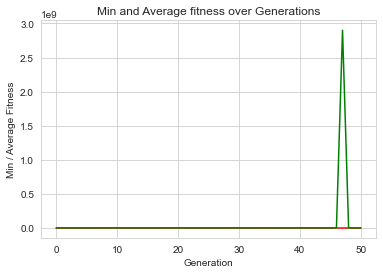

In [30]:
from deap import base, creator, tools

import random
import seaborn as sns
# import elitism

# problem constants:
DIMENSIONS = 2  # number of dimensions
BOUND_LOW, BOUND_UP = 4, 25  # boundaries for all dimensions

# Genetic Algorithm constants:
POPULATION_SIZE = 500
P_CROSSOVER = 0.8  # probability for crossover
P_MUTATION = 0.25   # (try also 0.5) probability for mutating an individual
MAX_GENERATIONS = 50
HALL_OF_FAME_SIZE = 30
CROWDING_FACTOR = 25.0  # crowding factor for crossover and mutation

# set the random seed:

toolbox = base.Toolbox()

# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)


# helper function for creating random real numbers uniformly distributed within a given range [low, up]
# it assumes that the range is the same for every dimension
def randomFloat(low, up):
    return [random.uniform(l, u) for l, u in zip([low] * DIMENSIONS, [up] * DIMENSIONS)]

# create an operator that randomly returns a float in the desired range and dimension:
toolbox.register("attrFloat", randomFloat, BOUND_LOW, BOUND_UP)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.attrFloat)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


# Eggholder function as the given individual's fitness:
def costo(individual):
    B = individual[0]
    P = individual[1]
    f = np.sum((V_r(pdist[5], B, P) - voltaje[5])**2) / 1000
#     f = (-(y + 47.0) * np.sin(np.sqrt(abs(x/2.0 + (y + 47.0)))) - x * np.sin(np.sqrt(abs(x - (y + 47.0)))))
    return f,  # return a tuple

toolbox.register("evaluate", costo)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR, indpb=1.0/DIMENSIONS)


# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with elitism:
    population, logbook = eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print info for best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations')

    plt.show()


if __name__ == "__main__":
    main()

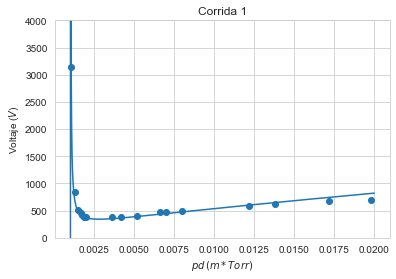

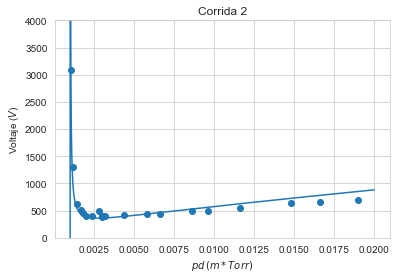

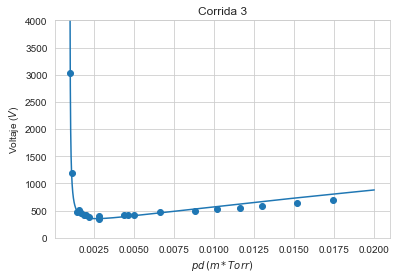

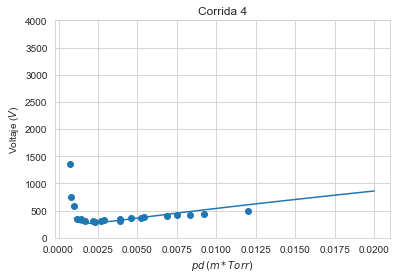

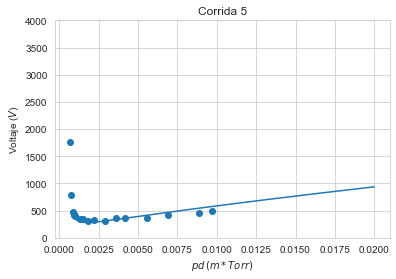

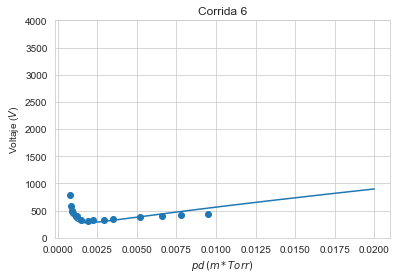

In [29]:
Coef = [];

# Datos para las curvas con d=20 cm
Coef.append([12.162367348671193, 6.872409764926862])
Coef.append([13.156721632826208, 6.894332401842585])
Coef.append([13.294253127601706, 6.932251194144382])

# Datos para las curvas con d=10 cm
Coef.append([14.645358586579123, 7.312424772204536])
Coef.append([16.147537392768477, 7.355209106798386])
Coef.append([15.276402745705540, 7.311807614509045])

X = np.linspace(0.001,0.02,10000)

# plt.figure(figsize=(10,6)); plt.grid()

labels = []
for k in range(6):
    labels.append("Corrida "+str(k+1))
    # plt.scatter(pdist[k],voltaje[k], label=labels[k])
    plt.title(labels[k])
    plt.scatter(pdist[k],voltaje[k])
    plt.plot(X, V_r(X, Coef[k][0], Coef[k][1]));
    plt.xlabel(r"$pd\, (m*Torr)$")
    plt.ylabel(r"Voltaje ($V$)")
    plt.ylim(bottom=0, top=4000)
    # plt.legend(); 
    plt.show()
